<a href="https://colab.research.google.com/github/DhanushV2006/AIML/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

def plot_decision_boundary(clf, X, y, title):
    plt.figure(figsize=(6, 5))
    ax = plt.gca()

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm,
               edgecolors='k', s=25)

    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())
    plt.show()

X, y = make_circles(n_samples=300, factor=0.3, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Kernel Accuracy: 0.42


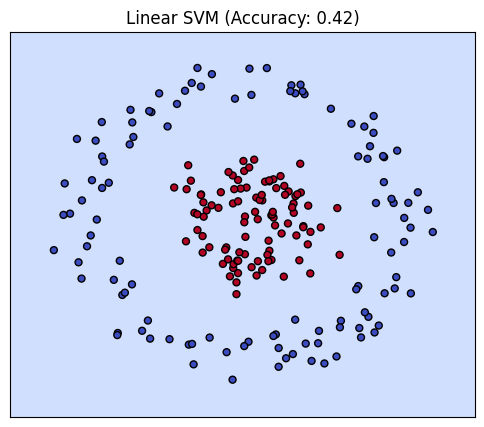

In [3]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

linear_preds = svm_linear.predict(X_test_scaled)
linear_acc = accuracy_score(y_test, linear_preds)

print(f"Linear Kernel Accuracy: {linear_acc:.2f}")

plot_decision_boundary(svm_linear, X_train_scaled, y_train,
                       f"Linear SVM (Accuracy: {linear_acc:.2f})")

Polynomial Kernel Accuracy: 0.42


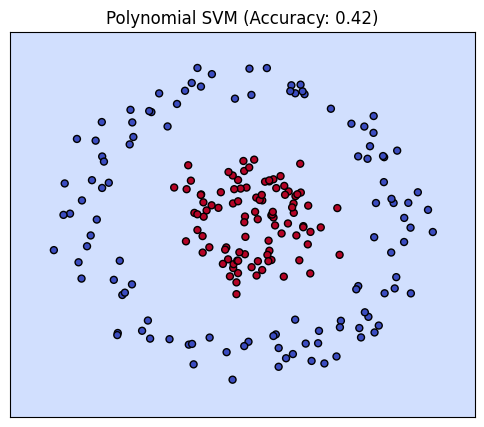

In [4]:
svm_poly = SVC(kernel='poly', degree=3, C=1.0)
svm_poly.fit(X_train_scaled, y_train)

poly_preds = svm_poly.predict(X_test_scaled)
poly_acc = accuracy_score(y_test, poly_preds)

print(f"Polynomial Kernel Accuracy: {poly_acc:.2f}")

plot_decision_boundary(svm_poly, X_train_scaled, y_train,
                       f"Polynomial SVM (Accuracy: {poly_acc:.2f})")